In [1]:
%load_ext autoreload
%autoreload 2

**I302 - Aprendizaje Automático y Aprendizaje Profundo**

<h1 style="text-align: center;">Proyecto Final: <strong>Predicción de Etapas del Sueño sobre Señales Fisiológicas con RNNs</strong></h1>

*Agustín A. Pereyra & Agustín Patruno*

---

In [2]:
from src.data import EDA, STAGES_LABELS
import src.plots as plots
import src.metrics as metrics

# Análisis Exploratorio de Datos (EDA)

## El Dataset

Se compone de datos de 47 pacientes (BidslabXX) sanos con grabaciones de entre 3 a 7 noches de (1) la frecuencia cardiaca instantánea (IHR) y (2) 3 ejes de acelerometría medidos por un Apple Watch con un total de 253 noches de datos. Cada época (lapsos de 30 segundos) vienen etiquetados por un experto (*expert_label*) y el dispotitivo "Dreem 2 Headband" (*dreem_label*), un monitor de sueño portátil.

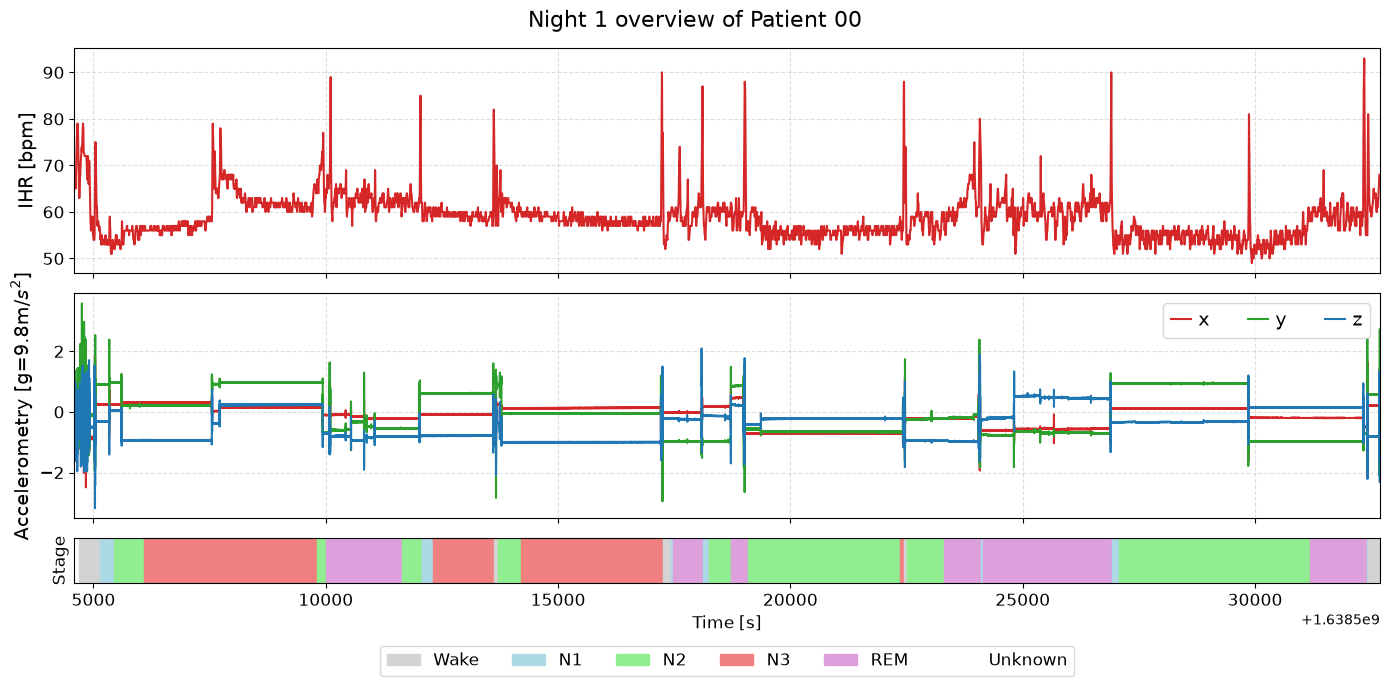

In [3]:
patient, night = 0, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

### Distribución de Etapas de Sueño

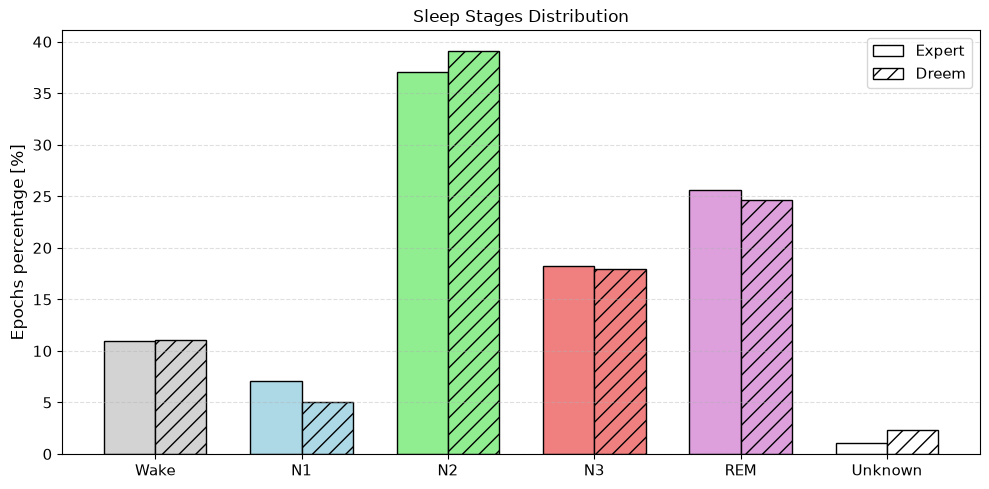

In [4]:
distributions = EDA.class_distribution()
plots.class_distribution(distributions)

### Labels "Expert" vs "Dreem"

**Cohen's Kappa** mide el *acuerdo* entre dos clasificadores (en este caso, el etiquetado del experto y el del dispositivo Dreem) corrigiendo por el acuerdo que se esperaría por azar dado el desbalance de clases (Cohen, 1960). Se define como:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde:
- $p_o$ es la **proporción observada de acuerdo** (accuracy): fracción de epochs donde ambos etiquetados coinciden.
- $p_e$ es la **proporción de acuerdo esperada por azar**, calculada a partir de las distribuciones marginales de cada clasificador: $p_e = \sum_k \frac{n_{k\cdot} \cdot n_{\cdot k}}{n^2}$, con $n_{k\cdot}$ y $n_{\cdot k}$ las marginales de fila/columna de la matriz de confusión y $n$ el total de epochs.

**Valores que puede tomar:**
- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo observado es igual al esperado por azar (no hay acuerdo más allá del azar).
- $\kappa < 0$: el acuerdo es peor que el azar (desacuerdo sistemático).
- En general $-1 \le \kappa \le 1$.

**Interpretación habitual [(Landis & Koch, 1977)](http://doi.org/10.2307/2529310):** $<0$ sin acuerdo, $0$–$0.2$ leve, $0.2$–$0.4$ aceptable, $0.4$–$0.6$ moderado, $0.6$–$0.8$ sustancial, $0.8$–$1$ casi perfecto.

Además del valor global, se calcula $\kappa$ **por clase** mediante un esquema one-vs-rest: para cada etapa $k$ se binariza el problema (¿es clase $k$ o no?) y se computa $\kappa$ sobre esa matriz de confusión 2x2, lo que permite identificar en qué etapas específicas el experto y Dreem difieren más.

In [5]:
expert, dreem = EDA.all_labels()
kappa_global = metrics.cohen_kappa(expert, dreem)
kappa_per_class = metrics.cohen_kappa_per_class(expert, dreem)

labels = ['K (global)'] + [f'K ({stage})' for stage in STAGES_LABELS.values()]
label_width = max(len(l) for l in labels)

print(f'{labels[0]:<{label_width}} = {kappa_global:.4f}')
for label, k in zip(labels[1:], kappa_per_class):
    print(f'{label:<{label_width}} = {k:.4f}')

K (global) = 0.0585
K (Wake)   = 0.0096
K (N1)     = 0.0169
K (N2)     = 0.0530
K (N3)     = 0.1228
K (REM)    = 0.0554
K (Unkown) = 0.0297


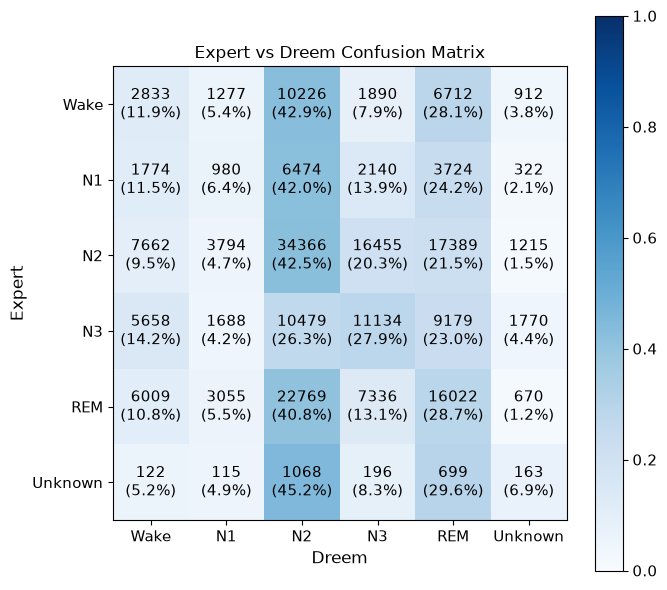

In [6]:
cm = metrics.confusion_matrix(expert, dreem)
plots.confusion_matrix(cm)